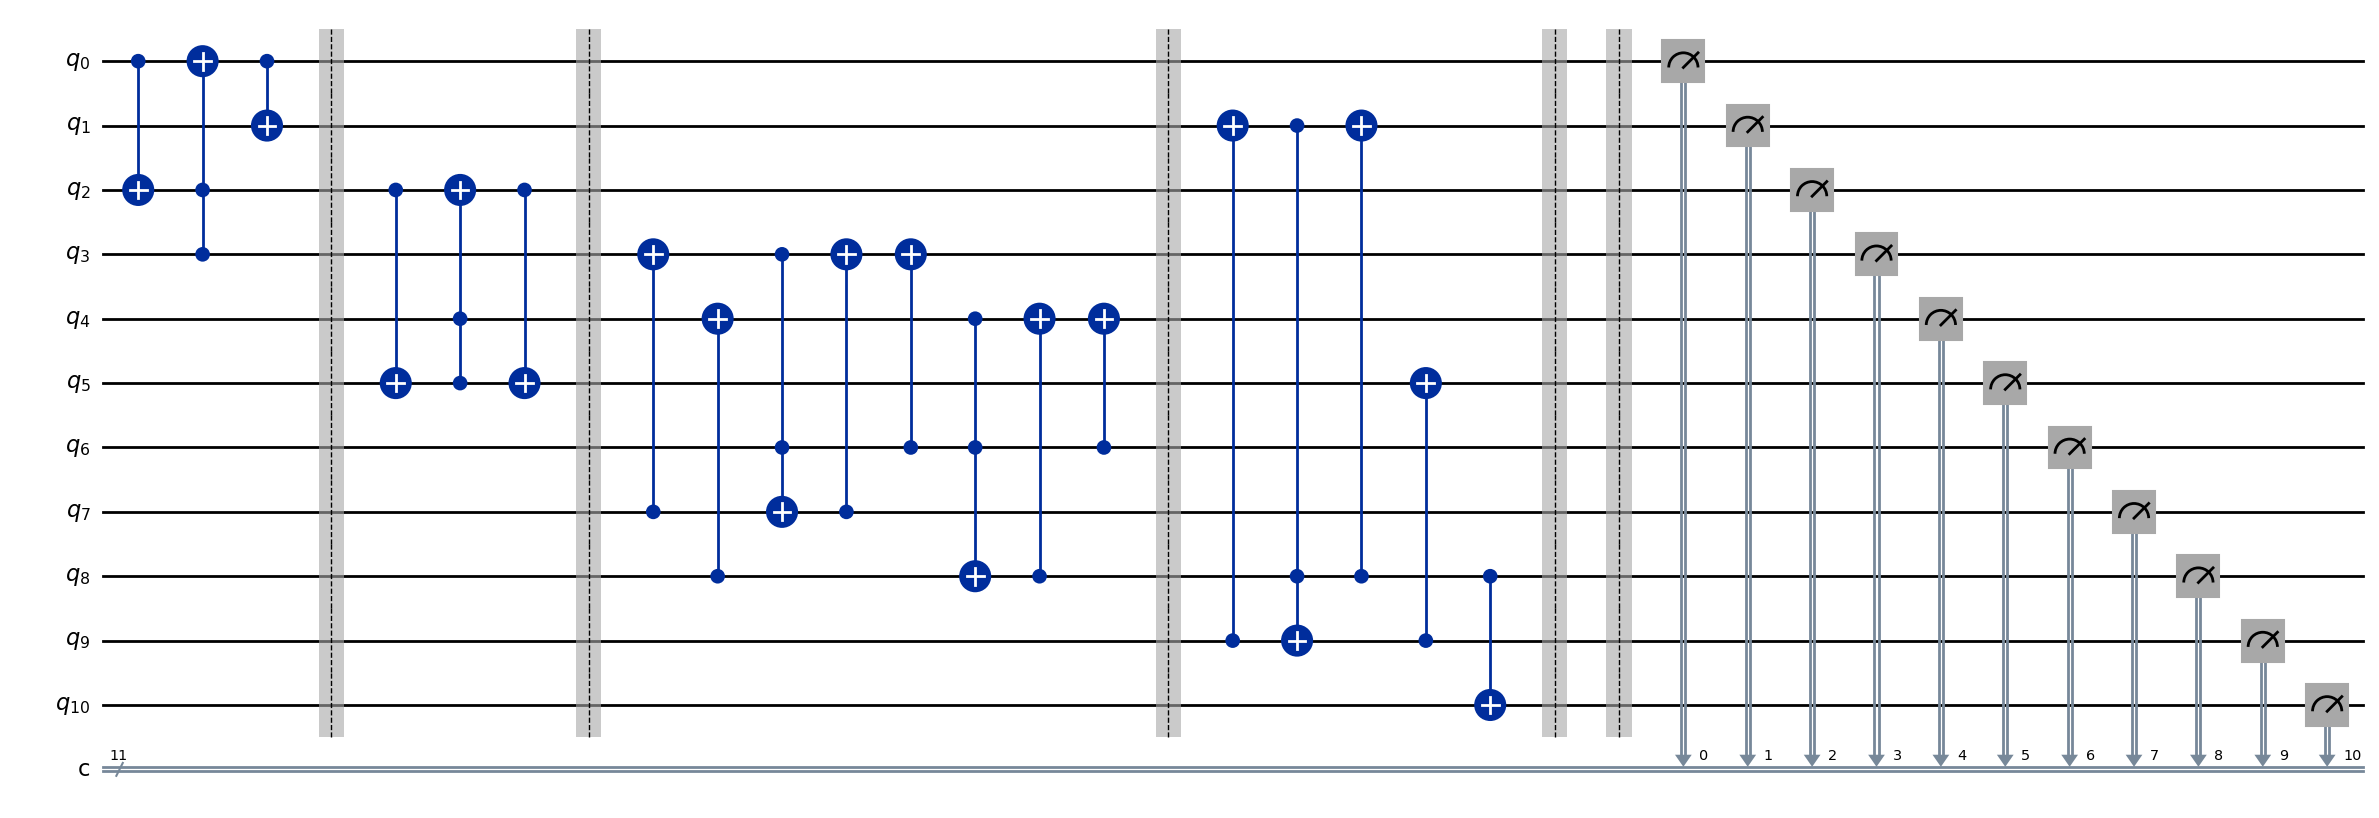

In [7]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, amplitude_damping_error, phase_damping_error
from qiskit.visualization import plot_histogram

# Initialize backend
backend = Aer.get_backend("aer_simulator") # Create a quantum circuit with 1 qubit and 1 classical bit

qc = QuantumCircuit(11,11)




## N1 original  GATE
qc.cx(0,2)
qc.ccx(3,2,0)
qc.cx(0,1)
qc.barrier()
##RF GATE
qc.cx(2,5)
qc.ccx(5,4,2)
qc.cx(2,5)
qc.barrier()
## A block
qc.cx(7,3)
qc.ccx(6,3,7)
qc.cx(7,3)
qc.cx(6,3)
qc.cx(8,4)
qc.ccx(6,4,8)
qc.cx(8,4)
qc.cx(6,4)
qc.barrier()
## N3 mod gate
qc.cx(9,1)
qc.ccx(8,1,9)
qc.cx(8,1)
qc.cx(8,10)
qc.cx(9,5)
qc.barrier()

qc.barrier()
qc.measure([0, 1, 2, 3,4,5,6,7,8,9,10], [0, 1, 2, 3,4,5,6,7,8,9,10])  # Measure all qubits


qc.draw('mpl', fold=90)


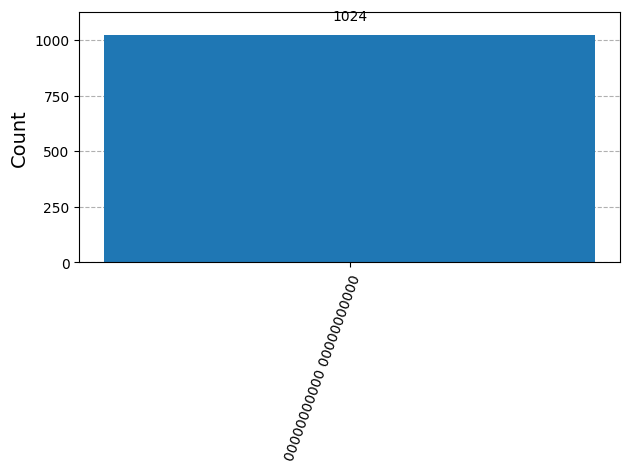

In [8]:
qc.measure_all()

job = backend.run(qc, shots=1024)
result = job.result()
counts = result.get_counts(qc)
plot_histogram(counts)